# Setup

In [209]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [210]:
# Imports for Training #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, ReLU, MaxPool2D, BatchNormalization, Concatenate
from tensorflow.keras.models import Model

import qkeras

In [211]:
# Constants #

IMAGE_X = 256
IMAGE_Y = 256

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

SCALE_FACTOR = 8

LABEL_X = IMAGE_X // SCALE_FACTOR
LABEL_Y = IMAGE_Y // SCALE_FACTOR

MIN_NUM_GAUSSIANS = 2
MAX_NUM_GAUSSIANS = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

THRESHOLD = 0.5

In [212]:
# Util Functions #

def img_gen(VERBOSE: bool = False) -> tuple:

    img = np.zeros(shape=(IMAGE_Y, IMAGE_X, 1))
    label = np.zeros(shape=(LABEL_Y, LABEL_X, 1))
    params = []

    num_gaussians = np.random.randint(low=MIN_NUM_GAUSSIANS, high=MAX_NUM_GAUSSIANS)
    for _ in range(num_gaussians):

        # Randomize params
        center_x = np.random.randint(low=0 + GAUSSIAN_X // 2, high=IMAGE_X - GAUSSIAN_X // 2)
        center_y = np.random.randint(low=0 + GAUSSIAN_Y // 2, high=IMAGE_Y - GAUSSIAN_Y // 2)

        std_x = np.random.randint(low=MIN_STD_X, high=MAX_STD_X)
        std_y = np.random.randint(low=MIN_STD_Y, high=MAX_STD_Y)
        theta = np.random.randint(low=MIN_THETA, high=MAX_THETA)
        
        intensity = np.random.uniform(low=MIN_INTENSITY, high=MAX_INTENSITY)
        
        # Generate Gaussian
        params.append((center_x, center_y, std_x, std_y, theta, intensity))
        gaussian = gaussian_gen(center_x, center_y, std_x, std_y, theta)

        # Add Gaussian to img
        img += intensity * gaussian
        # img += gaussian
        
        label_x = center_x // SCALE_FACTOR
        label_y = center_y // SCALE_FACTOR

        label[label_y, label_x] = 1

    # Convert to 8 bit int
    img = (img * 255).astype(np.uint8)

    # DEBUG
    if VERBOSE:
        # print(f"[Image Shape]: {str(img.shape)}")
        # print(f"[Label Shape]: {str(label.shape)}")
        print(f"[Target Gaussians #]: {str(num_gaussians)}")
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    return (img, label, params)

def gaussian_gen(center_x: int, center_y: int, std_x: int, std_y: int, theta: float) -> np.ndarray:
    
    X = np.arange(0, IMAGE_X, 1)
    Y = np.arange(0, IMAGE_Y, 1)
    X, Y = np.meshgrid(X, Y)

    cos_theta_sqrd = np.power(np.cos(theta),2)
    sin_theta_sqrd = np.power(np.sin(theta),2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(-(a * (X - center_x)**2 + 2*b * (X - center_x) * (Y - center_y) + c * (Y - center_y)**2))

    return np.expand_dims(gaussian, -1)

def img_visualization_one(img: np.ndarray, label: np.ndarray, params: list = None, threshold: int = THRESHOLD) -> None:
    
    rgb_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Coords of Gaussians:
    for x in range(LABEL_X):
        for y in range(LABEL_Y):
            if label[y, x,] >= threshold:
                
                top_left = (x * SCALE_FACTOR - GAUSSIAN_X // 2, y * SCALE_FACTOR - GAUSSIAN_Y // 2)
                bottom_right = (x * SCALE_FACTOR + GAUSSIAN_X // 2, y * SCALE_FACTOR + GAUSSIAN_Y // 2)
                color = (0, 200, 200)
                thickness = 2
                
                cv2.rectangle(rgb_image, top_left, bottom_right, color, thickness)

    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )
    
    plt.imshow(rgb_image)

def img_visualization_two(img: np.ndarray, label: np.ndarray, params: list = None) -> None:
    
    if params != None:
        for param in params:
            print(
            f"[(c_x, c_y)]: ({param[0]:<3}, {param[1]:<3}) "
            f"[(s_x, s_y)]: ({param[2]:<3}, {param[3]:<3}) "
            f"[Theta]: {param[4]:.2f} "
            f"[I]: {param[5]:.2f} "
            )

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    
    plt.subplot(1, 2, 2)
    plt.imshow(label, cmap='gray')

[(c_x, c_y)]: (79 , 84 ) [(s_x, s_y)]: (9  , 6  ) [Theta]: 0.00 [I]: 0.75 
[(c_x, c_y)]: (63 , 207) [(s_x, s_y)]: (9  , 5  ) [Theta]: 0.00 [I]: 0.26 


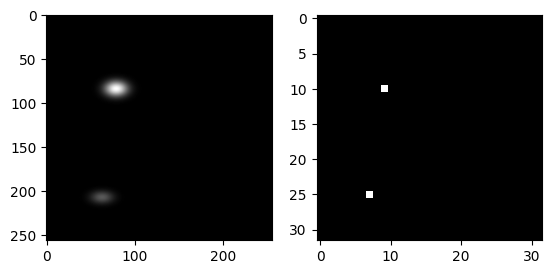

In [213]:
# Test Util Functions #

img, label, params = img_gen()
img_visualization_two(img, label, params)

In [214]:
# Generate Training Dataset #
SAMPLE_COUNT = 1000

img_arr = []
label_arr = []

def process_image():
    img, label, _ = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(SAMPLE_COUNT)]
    for future in tqdm(as_completed(futures), total=SAMPLE_COUNT):
        img, label = future.result()
        img_arr.append(img.astype(np.float32) / 256) # Normalize values to [0, 1)
        label_arr.append(label)

img_arr = np.array(img_arr).astype(np.float32)
label_arr = np.array(label_arr).astype(np.float32)

print(f'[Images Shape]: {img_arr.shape}')
print(f'[Labels Shape]: {label_arr.shape}')

100%|██████████| 1000/1000 [00:00<00:00, 1997.04it/s]


[Images Shape]: (1000, 256, 256, 1)
[Labels Shape]: (1000, 32, 32, 1)


# Training

In [215]:
# Convert Data to TF Dataset #
BATCH_SIZE = 25

dataset = tf.data.Dataset.from_tensor_slices((img_arr, label_arr))
dataset = dataset.shuffle(SAMPLE_COUNT, reshuffle_each_iteration=True)
dataset = dataset.batch(BATCH_SIZE)

In [216]:
# Model Architecture # 

input_layer = Input(shape=(IMAGE_X, IMAGE_Y, 1), name='InputLayer')

x = Conv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(input_layer)
x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2)(x)

x = Conv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(x)
x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2)(x)

x = Conv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(x)
x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)
x = ReLU()(x)
x = MaxPool2D(pool_size=2)(x)

x_prob = Conv2D(1, kernel_size=3, padding='same', name='x_prob', activation='sigmoid', kernel_initializer='lecun_uniform')(x)

baby_yolo_tf = Model(inputs=input_layer, outputs=x_prob, name='baby_yolo')

In [217]:
# Tensorflow Functions #

def loss_p(y_true, y_pred):
    loss = tf.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_sum(loss)

In [218]:
# Train or Load #
TRAIN_MODEL = False
LOAD_MODEL = True

MODEL_NAME = '[FOLO]_[Generated]_[256].keras'
NUM_EPOCHS = 100

if (TRAIN_MODEL and LOAD_MODEL):
    print("Are you sure you want to do both?")
    
elif (TRAIN_MODEL):

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.01,
        decay_steps=NUM_EPOCHS,
        decay_rate=0.9)
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    baby_yolo_tf.compile(optimizer=adam_optimizer, loss=loss_p, run_eagerly=True)

    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0
        
        for batch in tqdm(dataset):
            with tf.GradientTape() as tape:
                prediction = baby_yolo_tf(batch[0])
                loss = loss_p(batch[1], prediction)  # Compute the loss
            grads = tape.gradient(loss, baby_yolo_tf.trainable_variables)
            adam_optimizer.apply_gradients(zip(grads, baby_yolo_tf.trainable_variables))
            running_loss += loss.numpy()
            
        average_loss = running_loss / len(dataset)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {average_loss}")

elif (LOAD_MODEL):
    baby_yolo_tf = tf.keras.models.load_model(
        f'../Models/{MODEL_NAME}',
        custom_objects={"loss_p": loss_p}
    )

baby_yolo_tf.summary()

Model: "baby_yolo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ x_prob (Conv2D)                 │ (None, 32, 32, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,220 (59.46 KB)

 Trainable params: 5,041 (19.69 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 10,083 (39.39 KB)

In [219]:
# Save Model #
SAVE_MODEL = False

if (SAVE_MODEL):
    baby_yolo_tf.save(f'../Models/{MODEL_NAME}')

In [220]:
# Create Validation Dataset #
VAL_COUNT = 100

img_arr_val = []
label_arr_val = []

def process_image():
    img, label, _ = img_gen()
    return img, label

with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(VAL_COUNT)]
    for future in tqdm(as_completed(futures), total=VAL_COUNT):
        img, label = future.result()
        img_arr_val.append(img.astype(np.float32) / 256) # Normalize values to [0, 1)
        label_arr_val.append(label)

img_arr_val = np.array(img_arr_val).astype(np.float32)
label_arr_val = np.array(label_arr_val).astype(np.float32)

predictions_tf = baby_yolo_tf(img_arr_val)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_tf.shape}')

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 2270.14it/s]


[Validation Shape]: (100, 256, 256, 1)
[Prediction Shape]: (100, 32, 32, 1)


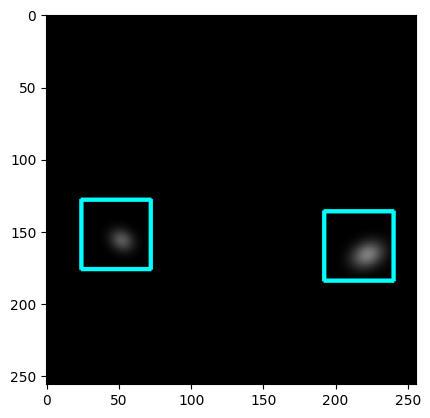

In [221]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

img_visualization_one(img_arr_val[index], predictions_tf[index])

# HLS4ML

In [ ]:
# HLS4ML Config #
 
import hls4ml
from hls4ml.utils import config_from_keras_model
from pprint import pprint

config = config_from_keras_model(baby_yolo_tf, granularity='model')
config['Model']['Strategy'] = 'Latency'
#config['Model']['ReuseFactor'] = 1
config['Model']['ReuseFactor'] = 1
     
config['Model']['Precision'] = 'fixed<16,6>'
#config['Model']['allow_da_fallback'] = False

# config['Flows'] = ['vivado:fifo_depth_optimization']
# hls4ml.model.optimizer.get_optimizer('vivado:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

# config['Flows'] = ['vitis:fifo_depth_optimization']
# hls4ml.model.optimizer.get_optimizer('vitis:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

pprint(config)

Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_1
da4ml not installed. Set `allow_da_fallback=False` to disable DA fallback.
Keras v2 handler used for layer batch_normalization_2
{'Model': {'BramFactor': 1000000000,
           'Precision': 'fixed<16,6>',
           'ReuseFactor': 1,
           'Strategy': 'resource',
           'TraceOutput': False}}


Function da_call requires da4ml<0.6,>=0.5.2, but package hgq is missing


In [223]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

Failed to import pydot. You must install pydot and graphviz for `pydotprint` to work.


In [224]:
# Compile & Predict #

hls_model = hls4ml.converters.convert_from_keras_model(
    baby_yolo_tf,
    hls_config=config,
    output_dir='../folo_hls4ml-quinlyn_re1_16_6',
    # io_type='io_stream',
    io_type='io_parallel',
    backend='vitis',
    part='xcku035-fbva676-2-e',
    project_name='folo',
    allow_da_fallback = False
)   

hls_model.compile()

predictions_hls4ml = hls_model.predict(img_arr_val).reshape(VAL_COUNT, LABEL_Y, LABEL_X)

print(f'[Validation Shape]: {img_arr_val.shape}')
print(f'[Prediction Shape]: {predictions_hls4ml.shape}')

Keras v2 handler used for layer batch_normalization
Keras v2 handler used for layer batch_normalization_1
Keras v2 handler used for layer batch_normalization_2


KeyboardInterrupt: 

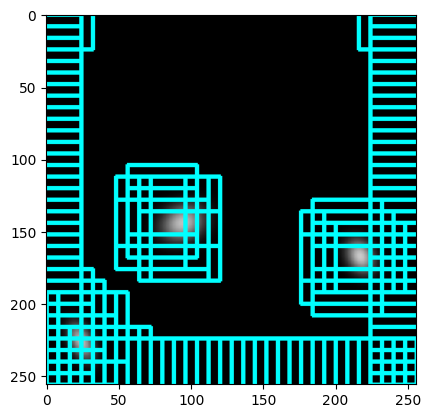

In [ ]:
# Visual Validation #
index = np.random.randint(low=0, high=VAL_COUNT)

img_visualization_one(img_arr_val[index], predictions_hls4ml[index], threshold=0.99)

In [ ]:
# Build Model #
# Run vitis_hls build_prj.tcl in SHELL

In [ ]:
# View Report #
hls4ml.report.read_vivado_report('../folo_hls4ml-quinlyn')

Found 1 solution(s) in ../folo_hls4ml-quinlyn/folo_prj.
Reports for solution "solution1":

C SIMULATION RESULT:
INFO: [SIM 2] *************** CSIM start ***************
INFO: [SIM 4] CSIM will launch CLANG as the compiler.
   Compiling ../../../../folo_test.cpp in debug mode
   Compiling ../../../../firmware/folo.cpp in debug mode
   Generating csim.exe
INFO: Unable to open input/predictions file, using default input.
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

# Qkeras

In [ ]:
# ## qkeras Model Architecture #
# from qkeras import * 
# # lecun_uniform
# input_layer = Input(shape=(IMAGE_X, IMAGE_Y, 1), name='InputLayer')

# x = QConv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(input_layer)
# x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)         # test Qkeras batchnormalization
# x = QActivation("quantized_relu(bits=16, integer=6, use_sigmoid=0)")(x)
# x = MaxPool2D(pool_size=2)(x)

# x = QConv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(x)
# x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)
# x = QActivation("quantized_relu(bits=16, integer=6, use_sigmoid=0)")(x)
# x = MaxPool2D(pool_size=2)(x)

# x = QConv2D(filters=16, kernel_size=3, strides=1, padding='same', kernel_initializer='lecun_uniform')(x)
# x = BatchNormalization(axis=-1, momentum=0.1, epsilon=1e-05)(x)
# x = QActivation("quantized_relu(bits=16, integer=6, use_sigmoid=0)")(x)
# x = MaxPool2D(pool_size=2)(x)

# x_prob = QConv2D(1, kernel_size=3, padding='same', name='x_prob', activation='sigmoid', kernel_initializer='lecun_uniform')(x)

# baby_yolo_q_tf = Model(inputs=input_layer, outputs=x_prob, name='baby_yolo_q')

In [ ]:
# baby_yolo_q_tf = Create

NameError: name 'Create' is not defined

In [ ]:
# from qkeras.utils import model_quantize

# config = {
#   "QConv2D": {
#       "kernel_quantizer": "stochastic_ternary",
#       "bias_quantizer": "quantized_po2(4)"
#   },
#   "QActivation": { "relu": "binary" },
#   "act_2": "quantized_relu(16, 6)",
# }

# qmodel = model_quantize(baby_yolo_q_tf, config, 4, transfer_weights=True)

# for layer in qmodel.layers:
#     if hasattr(layer, "kernel_quantizer"):
#         print(layer.name, "kernel:", str(layer.kernel_quantizer_internal), "bias:", str(layer.bias_quantizer_internal))
#     elif hasattr(layer, "quantizer"):
#         print(layer.name, "quantizer:", str(layer.quantizer))

# print()
# qmodel.summary()

# qmodel.compile(
#     loss="categorical_crossentropy",
#     optimizer=adam_optimizer,
#     metrics=["accuracy"])

# qmodel.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_test, y_test), verbose=True)

# #qmodel.load_weights("/home/quinlyn/Rheed/Rheed-FOLO/Models/[FOLO]_[Generated]_[256].keras", skip_mismatch=)

q_conv2d_8 kernel: None bias: None
q_activation_3 quantizer: quantized_relu(16,6)
q_conv2d_9 kernel: None bias: None
q_activation_4 quantizer: quantized_relu(16,6)
q_conv2d_10 kernel: None bias: None
q_activation_5 quantizer: quantized_relu(16,6)
x_prob kernel: None bias: None



Model: "baby_yolo_q"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_conv2d_8 (QConv2D)            │ (None, 256, 256, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_activation_3 (QActivation)    │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_conv2d_9 (QConv2D)            │ (None, 128, 128, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_activation_4 (QActivation)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_conv2d_10 (QConv2D)           │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_activation_5 (QActivation)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ x_prob (QConv2D)                │ (None, 32, 32, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,137 (20.07 KB)

 Trainable params: 5,041 (19.69 KB)

 Non-trainable params: 96 (384.00 B)

ValueError: A total of 4 objects could not be loaded. Example error message for object <QConv2D name=q_conv2d_8, built=True>:

Layer 'q_conv2d_8' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<QConv2D name=q_conv2d_8, built=True>, <QConv2D name=q_conv2d_9, built=True>, <QConv2D name=q_conv2d_10, built=True>, <QConv2D name=x_prob, built=True>]